# Implémentation & Test de Dream-MCMC avec sous-échantillonnage

In [1]:
from typing import List, Sequence, Union
from random import random, choice
from operator import attrgetter
from numbers import Number
import sys

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from scipy.interpolate import interp1d

from lagrange import Lagrange
from params import Param, ParamsPriors, Prior, PARAM_LIST
from state import State
from checker import checker

from utils import *
# (
#         C_W,
#     RHO_W,
#     LAMBDA_W,
#     compute_H_stratified,
#     compute_T_stratified,
#     conv,
#     compute_energy,
#     compute_log_acceptance,
#     convert_to_layer,
#     check_range,
#     gelman_rubin,
#     interface_transition,
# )
from layers import Layer, getListParameters, sortLayersList, AllPriors, LayerPriors


class Column:  # colonne de sédiments verticale entre le lit de la rivière et l'aquifère
    def __init__(
        self,
        river_bed: float,  # profondeur de la colonne en mètres
        # profondeur des capteurs de températures en mètres
        depth_sensors: Sequence[float],
        offset: float,  # correspond au décalage du capteur de température par rapport au lit de la rivière
        # liste contenant un tuple avec la date, la charge et la température au sommet de la colonne
        dH_measures: list,
        T_measures: list,  # liste contenant un tuple avec la date et la température aux points de mesure de longueur le nombre de temps mesuré
        sigma_meas_P: float,  # écart type de l'incertitude sur les valeurs de pression capteur
        sigma_meas_T: float,  # écart type de l'incertitude sur les valeurs de température capteur
        # mode d'interpolation du profil de température initial : 'lagrange' ou 'linear'
        inter_mode: str = "linear",
    ):
        # ! Pour l'instant on suppose que les temps matchent
        self._times = [t for t, _ in dH_measures]
        # récupère la liste des charges de la riviière (au cours du temps)
        self._dH = np.array([d for _, (d, _) in dH_measures])
        # récupère la liste de température de la rivière (au cours du temps)
        self._T_riv = np.array([t for _, (_, t) in dH_measures])
        # récupère la liste de température de l'aquifère (au cours du temps)
        self._T_aq = np.array([t[-1] for _, t in T_measures])
        # récupère la liste de températures des capteurs (au cours du temps)
        self._T_measures = np.array([t[:-1] for _, t in T_measures])

        # décale d'un offset les positions des capteurs de température (aussi riviere)
        self._real_z = np.array([0] + depth_sensors) + offset
        # enlève l'offset sur la mesure de température rivière car cette mesure est prise dans le capteur pression
        self._real_z[0] -= offset

        self.depth_sensors = depth_sensors
        self.offset = offset

        self._layersList = None

        self._z_solve = (
            None  # le tableau contenant la profondeur du milieu des cellules
        )
        self._id_sensors = None
        # le tableau contenant les températures à tout temps et à toute profondeur (lignes : températures) (colonnes : temps)
        self._temps = None
        # le tableau contenant les charges à tout temps et à toute profondeur (lignes : charges) (colonnes : temps)
        self._H_res = None
        # le tableau contenant le débit spécifique à tout temps et à toute profondeur (lignes : débit) (colonnes : temps)
        self._flows = None

        # liste contenant des objets de classe état et de longueur le nombre d'états acceptés par la MCMC (<=nb_iter), passe à un moment par une longueur de 1000 pendant l'initialisation de MCMC
        self._states = None
        self._initial_energies = None
        self._acceptances = None
        # dictionnaire indexé par les quantiles (0.05,0.5,0.95) à qui on a associe un array de deux dimensions : dimension 1 les profondeurs, dimension 2 : liste des valeurs de températures associées au quantile, de longueur les temps de mesure
        self._quantiles_temps = None
        # dictionnaire indexé par les quantiles (0.05,0.5,0.95) à qui on a associe un array de deux dimensions : dimension 1 les profondeurs, dimension 2 : liste des valeurs de débits spécifiques associés au quantile, de longueur les temps de mesure
        self._quantiles_flows = None
        self.lagr = Lagrange(
            np.array(self._real_z),
            np.array([self._T_riv[0], *self._T_measures[0], self._T_aq[0]]),
        )  # crée le polynome interpolateur de lagrange faisant coincider les températures connues à la profondeur réelle
        self.linear = interp1d(
            self._real_z, [self._T_riv[0], *self._T_measures[0], self._T_aq[0]]
        )
        # crée la fonction affine par morceaux faisant coincider les températures connues à la profondeur réelle
        self.inter_mode = inter_mode
        self.tests()  # teste que les conditions nécessaires à l'analyse sont remplies

    def tests(self):
        # teste que les données sont aux bons formats
        if np.shape(self._dH) != np.shape(self._T_aq) or (
            np.shape(self._dH) != np.shape(self._T_riv)
            or (np.shape(self._T_measures[1]) != (3,))
        ):
            raise NameError("Problème dans la taille des donées")

        # teste qu'il ne manque pas de données pour les conditions aux limites
        if np.isnan(np.sum(self._T_aq)):
            raise NameError("Donnée(s) manquante(s) pour la température aquifère")

        if np.isnan(np.sum(self._T_riv)):
            raise NameError("Donnée(s) manquante(s) pour la température rivière")

        if np.isnan(np.sum(self._dH)):
            raise NameError("Donnée(s) manquante(s) pour la pression")

    @classmethod
    def from_dict(cls, col_dict):
        """
        Class method to create an instance of Column from a dictionnary.
        """
        return cls(**col_dict)

    def _check_layers(self, layersList):
        """
        Initializes the _layersList attribute with layersList sorted by zLow.
        Checks the last layer's zLow matches the end of the column.
        """
        self._layersList = sortLayersList(layersList)

        if len(self._layersList) == 0:
            raise ValueError("Your list of layers is empty.")

        if self._layersList[-1].zLow != self._real_z[-1]:
            self._layersList[-1].zLow = self._real_z[-1]
            # raise ValueError(
            #     "Last layer does not match the end of the column.")

    def _compute_solve_transi_multiple_layers(self, layersList, nb_cells, verbose):
        dz = self._real_z[-1] / nb_cells  # profondeur d'une cellule
        self._z_solve = dz / 2 + np.array([k * dz for k in range(nb_cells)])

        self._id_sensors = [
            np.argmin(np.abs(z - self._z_solve)) for z in self._real_z[1:-1]
        ]

        all_dt = np.array(
            [
                (self._times[j + 1] - self._times[j]).total_seconds()
                for j in range(len(self._times) - 1)
            ]
        )  # le tableau des pas de temps (dépend des données d'entrée)
        isdtconstant = np.all(all_dt == all_dt[0])

        H_init = self._dH[0] - self._dH[0] * self._z_solve / self._real_z[-1]
        # fixe toutes les charges de l'aquifère à 0 (à tout temps)
        H_aq = np.zeros(len(self._times))
        H_riv = (
            self._dH
        )  # self.dH contient déjà les charges de la rivière à tout temps, stocke juste dans une variable locale
        # crée les températures initiales (t=0) sur toutes les profondeurs (milieu des cellules)

        if self.inter_mode == "lagrange":
            T_init = np.array([self.lagr(z) for z in self._z_solve])
        elif self.inter_mode == "linear":
            T_init = self.linear(self._z_solve)
        T_riv = self._T_riv
        T_aq = self._T_aq

        moinslog10K_list, n_list, lambda_s_list, rhos_cs_list = getListParameters(
            layersList, nb_cells
        )

        heigth = abs(self._real_z[-1] - self._real_z[0])
        Ss_list = (
            n_list / heigth
        )  # l'emmagasinement spécifique = porosité sur la hauteur

        if verbose:
            print("--- Compute Solve Transi ---")
            for layer in layersList:
                print(layer)

        H_res = compute_H_stratified(
            moinslog10K_list, Ss_list, all_dt, isdtconstant, dz, H_init, H_riv, H_aq
        )

        T_res = compute_T_stratified(
            moinslog10K_list,
            n_list,
            lambda_s_list,
            rhos_cs_list,
            all_dt,
            dz,
            H_res,
            H_riv,
            H_aq,
            T_init,
            T_riv,
            T_aq,
        )

        self._temps = T_res
        self._H_res = H_res  # stocke les résultats

        # création d'un tableau du gradient de la charge selon la profondeur, calculé à tout temps
        nablaH = np.zeros((nb_cells, len(self._times)), np.float32)

        nablaH[0, :] = 2 * (H_res[1, :] - H_riv) / (3 * dz)

        for i in range(1, nb_cells - 1):
            nablaH[i, :] = (H_res[i + 1, :] - H_res[i - 1, :]) / (2 * dz)

        nablaH[nb_cells - 1, :] = 2*(H_aq - H_res[nb_cells - 2, :])/(3*dz)
        
        K_list0 = 10 ** - moinslog10K_list
        K_list = interface_transition(K_list0)
        
        flows = np.zeros((nb_cells, len(self._times)), np.float32)

        for i in range(nb_cells):
            flows[i, :] = -K_list[i] * nablaH[i, :]

        self._flows = flows  # calcul du débit spécifique

        if verbose:
            print("Done.")

    @checker
    def compute_solve_transi(
        self, layersList: Union[tuple, Sequence[Layer]], nb_cells: int, verbose=True
    ):
        """
        Computes H, T and flow for each time and depth of the discretization of the column.
        """
        if isinstance(layersList, tuple):
            layer = [
                Layer(
                    "Layer 1",
                    self._real_z[-1],
                    layersList[0],
                    layersList[1],
                    layersList[2],
                    layersList[3],
                )
            ]
            self.compute_solve_transi(layer, nb_cells, verbose)

        else:
            # Checking the layers are well defined
            self._check_layers(layersList)
            self._compute_solve_transi_multiple_layers(
                self._layersList, nb_cells, verbose
            )

    @compute_solve_transi.needed
    def get_id_sensors(self):
        """
        Returns
        -------
        self._id_sensors : int list
            list of the 3 indices of the cells where the non boundary sensors are.
        """
        return self._id_sensors

    @compute_solve_transi.needed
    def get_RMSE(self):
        """
        Returns
        -------
        res : float array
            array with 4 elements which contains the RMSE for the non boundary sensors, and the total RMSE
        """

        # Number of sensors (except boundary conditions : river and aquifer)
        nb_sensors = len(self._T_measures[0])

        # Number of times for which we have measures
        nb_times = len(self._T_measures)

        # Array of RMSE for each sensor
        list_RMSE = np.array(
            [
                np.sqrt(
                    np.nansum((self.get_temps_solve()[id, :] - temps_obs) ** 2)
                    / nb_times
                )
                for id, temps_obs in zip(self.get_id_sensors(), self._T_measures.T)
            ]
        )

        # Total RMSE
        total_RMSE = np.sqrt(np.nansum(list_RMSE**2) / nb_sensors)

        return np.append(list_RMSE, total_RMSE)

    # erreur si pas déjà éxécuté compute_solve_transi, sinon l'attribut pas encore affecté à une valeur
    @compute_solve_transi.needed
    def get_depths_solve(self):
        """
        Returns
        -------
        self._z_solve : float array
            array of the depths of the middle of each cell.
        """
        return self._z_solve

    depths_solve = property(get_depths_solve)
    # récupération de l'attribut _z_solve

    def get_times_solve(self):
        """
        Returns
        -------
        self._times : datetime list
            list of the times at which the temperatures are computed.
        """
        return self._times

    times_solve = property(get_times_solve)
    # récupération de l'attribut _times

    # erreur si pas déjà éxécuté compute_solve_transi, sinon l'attribut pas encore affecté à une valeur
    @compute_solve_transi.needed
    def get_temps_solve(self, z=None):
        if z is None:
            return self._temps
        z_ind = np.argmin(np.abs(self.depths_solve - z))
        return self._temps[z_ind, :]

    temps_solve = property(get_temps_solve)
    # récupération des températures au cours du temps à toutes les profondeurs (par défaut) ou bien à une profondeur donnée

    # erreur si pas déjà éxécuté compute_solve_transi, sinon l'attribut pas encore affecté à une valeur
    @compute_solve_transi.needed
    def get_advec_flows_solve(self):
        return RHO_W * C_W * self._flows * (self.temps_solve - 273.15)

    advec_flows_solve = property(get_advec_flows_solve)
    # récupération des flux advectifs = masse volumnique*capacité calorifique*débit spécifique*température

    # erreur si pas déjà éxécuté compute_solve_transi, sinon l'attribut pas encore affecté à une valeur
    @compute_solve_transi.needed
    def get_conduc_flows_solve(self):
        dz = self._z_solve[1] - self._z_solve[0]  # pas en profondeur
        nb_cells = len(self._z_solve)

        _, n_list, lambda_s_list, _ = getListParameters(self._layersList, nb_cells)

        lambda_m_list = (
            n_list * (LAMBDA_W) ** 0.5 + (1.0 - n_list) * (lambda_s_list) ** 0.5
        ) ** 2  # conductivité thermique du milieu poreux équivalent
        
        # création du gradient de température
        nablaT = np.zeros((nb_cells, len(self._times)), np.float32)

        nablaT[0, :] = 2 * (self._temps[1, :] - self._T_riv) / (3 * dz)

        for i in range(1, nb_cells - 1):
            nablaT[i, :] = (self._temps[i + 1, :] - self._temps[i - 1, :]) / (2 * dz)

        nablaT[nb_cells - 1, :] = (
            2 * (self._T_aq - self._temps[nb_cells - 2, :]) / (3 * dz)
        )

        conduc_flows = np.zeros((nb_cells, len(self._times)), np.float32)
        
        for i in range(nb_cells):
            conduc_flows[i, :] = lambda_m_list[i] * nablaT[i, :]

        return conduc_flows

    conduc_flows_solve = property(get_conduc_flows_solve)
    # récupération des flux conductifs = conductivité*gradient(T)

    # erreur si pas déjà éxécuté compute_solve_transi, sinon l'attribut pas encore affecté à une valeur
    @compute_solve_transi.needed
    def get_flows_solve(self, z=None):
        if z is None:
            return self._flows  # par défaut, retourne le tableau des débits spécifiques
        z_ind = np.argmin(np.abs(self.depths_solve - z))
        # sinon ne les retourne que pour la profondeur choisie
        return self._flows[z_ind, :]

    flows_solve = property(get_flows_solve)
    # récupération des débits spécifiques au cours du temps à toutes les profondeurs (par défaut) ou bien à une profondeur donnée

    def compute_mcmc_without_sigma2(
        self,
        nb_iter: int,
        all_priors: Union[
            AllPriors,
            Sequence[
                Union[
                    LayerPriors,
                    Sequence[Union[str, float, Sequence[Union[Prior, dict]]]],
                ]
            ],
        ],
        nb_cells: int,
        quantile: Union[float, Sequence[float]] = (0.05, 0.5, 0.95),
        verbose=True,
        sigma2=1.0,
    ):
        if isinstance(quantile, Number):
            quantile = [quantile]

        def conv(layer):
            name, prof, priors = layer
            if isinstance(priors, dict):
                return (
                    name,
                    prof,
                    [Prior(*args) for args in (priors[lbl] for lbl in PARAM_LIST)],
                )
            else:
                return layer

        if not isinstance(all_priors, AllPriors):
            all_priors = AllPriors([LayerPriors(*conv(layer)) for layer in all_priors])

        dz = self._real_z[-1] / nb_cells
        _z_solve = dz / 2 + np.array([k * dz for k in range(nb_cells)])
        ind_ref = [np.argmin(np.abs(z - _z_solve)) for z in self._real_z[1:-1]]
        temp_ref = self._T_measures[:, :].T

        def compute_energy(temp: np.array):
            norm2 = np.nansum((temp - temp_ref) ** 2)
            return 0.5 * norm2 / sigma2

        def compute_log_acceptance(actual_energy: float, prev_energy: float):
            return prev_energy - actual_energy

        if verbose:
            print(
                "--- Compute Mcmc ---",
                "Priors :",
                *(f"    {prior}" for prior in all_priors),
                f"Number of cells : {nb_cells}",
                f"Number of iterations : {nb_iter}",
                "Launch Mcmc",
                sep="\n",
            )

        self._states = list()
        _temps = np.zeros((nb_iter + 1, nb_cells, len(self._times)), np.float32)
        _flows = np.zeros((nb_iter + 1, nb_cells, len(self._times)), np.float32)

        for _ in trange(1000, desc="Init Mcmc ", file=sys.stdout):
            init_layers = all_priors.sample()
            self.compute_solve_transi(init_layers, nb_cells, verbose=False)
            self._states.append(
                State(
                    layers=init_layers,
                    energy=compute_energy(self.temps_solve[ind_ref, :]),
                    ratio_accept=1,
                    sigma2_temp=sigma2,
                )
            )

        self._initial_energies = [state.energy for state in self._states]
        self._states = [min(self._states, key=attrgetter("energy"))]
        self._acceptance = np.zeros(nb_iter)

        _temps[0] = self.get_temps_solve()
        _flows[0] = self.get_flows_solve()

        nb_accepted = 0

        for i in trange(nb_iter, desc="Mcmc Computation ", file=sys.stdout):
            current_layers = all_priors.perturb(self._states[-1].layers)
            self.compute_solve_transi(current_layers, nb_cells, verbose=False)
            energy = compute_energy(self.temps_solve[ind_ref, :])
            log_ratio_accept = compute_log_acceptance(energy, self._states[-1].energy)
            if np.log(random()) < log_ratio_accept:
                nb_accepted += 1
                self._states.append(
                    State(
                        layers=current_layers,
                        energy=energy,
                        ratio_accept=nb_accepted / (i + 1),
                        sigma2_temp=sigma2,
                    )
                )
            else:
                self._states.append(self._states[-1])

            _temps[i] = self.get_temps_solve()
            _flows[i] = self.get_flows_solve()
            self._acceptance[i] = nb_accepted / (i + 1)

        # self.compute_solve_transi.reset()

        self._quantiles_temps = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_temps, quantile, axis=0))
        }
        self._quantiles_flows = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_flows, quantile, axis=0))
        }
        if verbose:
            print("Quantiles Done.")

    def compute_mcmc_with_sigma2(
        self,
        nb_iter: int,
        all_priors: Union[
            AllPriors,
            Sequence[
                Union[
                    LayerPriors,
                    Sequence[Union[str, float, Sequence[Union[Prior, dict]]]],
                ]
            ],
        ],
        nb_cells: int,
        quantile: Union[float, Sequence[float]] = (0.05, 0.5, 0.95),
        verbose=True,
        sigma2_temp_prior: Prior = Prior((0.01, np.inf), 1, lambda x: 1 / x),
    ):
        if isinstance(quantile, Number):
            quantile = [quantile]

        if not isinstance(all_priors, AllPriors):
            all_priors = AllPriors([LayerPriors(*conv(layer)) for layer in all_priors])

        dz = self._real_z[-1] / nb_cells
        _z_solve = dz / 2 + np.array([k * dz for k in range(nb_cells)])
        ind_ref = [np.argmin(np.abs(z - _z_solve)) for z in self._real_z[1:-1]]
        temp_ref = self._T_measures[:, :].T

        def compute_energy(temp: np.array, sigma2, sigma2_distrib):
            norm2 = np.nansum((temp - temp_ref) ** 2)
            return (
                0.5 * norm2 / sigma2
                + np.size(self._T_measures) * np.log(sigma2) / 2
                - np.log(sigma2_distrib(sigma2))
            )

        def compute_log_acceptance(actual_energy: float, prev_energy: float):
            return prev_energy - actual_energy

        if verbose:
            print(
                "--- Compute Mcmc ---",
                "Priors :",
                *(f"    {prior}" for prior in all_priors),
                f"Number of cells : {nb_cells}",
                f"Number of iterations : {nb_iter}",
                "Launch Mcmc",
                sep="\n",
            )

        self._states = list()
        _temps = np.zeros((nb_iter + 1, nb_cells, len(self._times)), np.float32)
        _flows = np.zeros((nb_iter + 1, nb_cells, len(self._times)), np.float32)

        for _ in trange(1000, desc="Init Mcmc ", file=sys.stdout):
            init_layers = all_priors.sample()
            init_sigma2_temp = sigma2_temp_prior.sample()
            self.compute_solve_transi(init_layers, nb_cells, verbose=False)
            self._states.append(
                State(
                    layers=init_layers,
                    energy=compute_energy(
                        self.temps_solve[ind_ref, :],
                        sigma2=init_sigma2_temp,
                        sigma2_distrib=sigma2_temp_prior.density,
                    ),
                    ratio_accept=1,
                    sigma2_temp=init_sigma2_temp,
                )
            )

        self._initial_energies = [state.energy for state in self._states]
        self._states = [min(self._states, key=attrgetter("energy"))]
        self._acceptance = np.zeros(nb_iter)

        _temps[0] = self.get_temps_solve()
        _flows[0] = self.get_flows_solve()

        nb_accepted = 0

        for i in trange(nb_iter, desc="Mcmc Computation ", file=sys.stdout):
            current_layers = all_priors.perturb(self._states[-1].layers)
            current_sigma2_temp = sigma2_temp_prior.perturb(
                self._states[-1].sigma2_temp
            )
            self.compute_solve_transi(current_layers, nb_cells, verbose=False)
            energy = compute_energy(
                self.temps_solve[ind_ref, :],
                sigma2=current_sigma2_temp,
                sigma2_distrib=sigma2_temp_prior.density,
            )
            log_ratio_accept = compute_log_acceptance(energy, self._states[-1].energy)
            if np.log(random()) < log_ratio_accept:
                nb_accepted += 1
                self._states.append(
                    State(
                        layers=current_layers,
                        energy=energy,
                        ratio_accept=nb_accepted / (i + 1),
                        sigma2_temp=current_sigma2_temp,
                    )
                )
            else:
                self._states.append(self._states[-1])

            _temps[i] = self.get_temps_solve()
            _flows[i] = self.get_flows_solve()
            self._acceptance[i] = nb_accepted / (i + 1)

        # self.compute_solve_transi.reset()

        self._quantiles_temps = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_temps, quantile, axis=0))
        }
        self._quantiles_flows = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_flows, quantile, axis=0))
        }
        if verbose:
            print("Quantiles Done.")

    def compute_dream_mcmc_without_sigma2(
        self,
        nb_iter: int,
        all_priors: Union[
            AllPriors,
            Sequence[
                Union[
                    LayerPriors,
                    Sequence[Union[str, float, Sequence[Union[Prior, dict]]]],
                ]
            ],
        ],
        nb_cells: int,
        quantile: Union[float, Sequence[float]] = (0.05, 0.5, 0.95),
        verbose=False,
        sigma2=1.0,
        nb_chain=10,
        delta=3,
        ncr=3,
        c=0.1,
        c_star=1e-6,
    ):
        # vérification des types des arguments
        if isinstance(quantile, Number):
            quantile = [quantile]

        if not isinstance(all_priors, AllPriors):
            all_priors = AllPriors([LayerPriors(*conv(layer)) for layer in all_priors])

        # définition des paramètres de la simulation
        dz = self._real_z[-1] / nb_cells
        _z_solve = dz / 2 + np.array([k * dz for k in range(nb_cells)])
        ind_ref = [np.argmin(np.abs(z - _z_solve)) for z in self._real_z[1:-1]]
        temp_ref = self._T_measures[:, :].T

        # quantités des différents paramètres
        nb_layer = len(all_priors)  # nombre de couches
        nb_param = 4  # nombre de paramètres à estimer par couche
        nb_accepted = 0  # nombre de propositions acceptées
        nb_burn_in_iter = 0  # nombre d'itération de burn-in

        # création des bornes des paramètres
        ranges = np.empty((nb_layer, nb_param, 2))
        for l in range(nb_layer):
            for p in range(nb_param):
                ranges[l, p] = all_priors[l][p].range

        # propriétés des couches
        name_layer = [all_priors.sample()[i].name for i in range(nb_layer)]
        z_low = [all_priors.sample()[i].zLow for i in range(nb_layer)]

        # stockage pour le burn-in, supprimé par la suite
        _temp_act = np.zeros(
            (nb_chain, nb_cells, len(self._times)), np.float32
        )
        _temp_old = np.zeros(
            (nb_chain, nb_cells, len(self._times)), np.float32
        ) # Conservation du dernier profil accepté
        _energy_burn_in = np.zeros((nb_iter + 1, nb_chain))

        # variables pour l'état courant
        temp_new = np.zeros((nb_cells, len(self._times)))
        energy_new = 0
        X = np.array([np.array(all_priors.sample()) for _ in range(nb_chain)])
        X = np.array(
            [
                np.array([X[c][l].params for l in range(nb_layer)])
                for c in range(nb_chain)
            ]
        )  # stockage des paramètres pour l'itération en cours

        # stockage des résultats
        self._states = list()  # stockage des états à chaque itération
        self._acceptance = np.zeros(
            (nb_iter, nb_chain)
        )  # stockage des taux d'acceptation

        _params = np.zeros(
            (nb_iter + 1, nb_chain, nb_layer, nb_param)
        )  # stockage des paramètres
        _params[0] = X  # initialisation des paramètres

        # objets liés à DREAM
        cr_vec = np.arange(1, ncr + 1) / ncr
        n_id = np.zeros((nb_layer, ncr))
        J = np.zeros((nb_layer, ncr))
        pcr = np.ones((nb_layer, ncr)) / ncr

        if verbose:
            print(
                "--- Compute DREAM MCMC ---",
                "Priors :",
                *(f"    {prior}" for prior in all_priors),
                f"Number of cells : {nb_cells}",
                f"Number of iterations : {nb_iter}",
                f"Number of chains : {nb_chain}",
                "--------------------",
                sep="\n",
            )

        # initialisation des chaines
        for i in range(nb_chain):
            self.compute_solve_transi(
                convert_to_layer(nb_layer, name_layer, z_low, X[i]),
                nb_cells,
                verbose=False,
            )
            _temp_act[i] = self.get_temps_solve()
            _energy_burn_in[0][i] = compute_energy(
                _temp_act[i][ind_ref, :], temp_ref, sigma2
            )

        if verbose:
            print("--- Begin Burn in phase ---")
        for i in range(nb_iter):
            # Initialisation pour les nouveaux paramètres
            x_new = np.zeros((nb_layer, nb_param))
            X_new = np.zeros((nb_chain, nb_layer, nb_param))
            std_X = np.std(X, axis=0)  # calcul des écarts types des paramètres
            for j in range(nb_chain):
                dX = np.zeros((nb_layer, nb_param))  # perturbation DREAM
                for l in range(nb_layer):
                    # actualiation des paramètres DREAM pour la couche l
                    id = np.random.choice(ncr, p=pcr[l])
                    z = np.random.uniform(0, 1, nb_param)
                    A = z <= cr_vec[id]
                    d_star = np.sum(A)
                    if d_star == 0:
                        A[np.argmin(z)] = True
                        d_star = 1
                    lambd = np.random.uniform(-c, c, d_star)
                    zeta = np.random.normal(0, c_star, d_star)
                    choose = np.delete(np.arange(nb_chain), j)
                    a = np.random.choice(choose, delta, replace=False)
                    choose = np.delete(choose, np.where(np.isin(choose, a)))
                    b = np.random.choice(choose, delta, replace=False)

                    gamma = 2.38 / np.sqrt(2 * d_star * delta)
                    dX[l][A] = zeta + (1 + lambd) * gamma * np.sum(
                        X[a, l][:, A] - X[b, l][:, A], axis=0
                    )

                    x_new[l] = X[j, l] + dX[l]  # caclul du potentiel nouveau paramètre
                    x_new[l] = check_range(
                        x_new[l], ranges[l]
                    )  # vérification des bornes et réajustement si besoin

                # Calcul du profil de température associé aux nouveaux paramètres
                self.compute_solve_transi(
                    convert_to_layer(nb_layer, name_layer, z_low, x_new),
                    nb_cells,
                    verbose=False,
                )
                temp_new = (
                    self.get_temps_solve()
                )  # récupération du profil de température
                energy_new = compute_energy(
                    temp_new[ind_ref, :], temp_ref, sigma2
                )  # calcul de l'énergie

                # calcul de la probabilité d'acceptation
                log_ratio_accept = compute_log_acceptance(
                    energy_new, _energy_burn_in[i][j]
                )

                # Acceptation ou non des nouveaux paramètres
                if np.log(np.random.uniform(0, 1)) < log_ratio_accept:
                    X_new[j] = x_new  # actualisation des paramètres pour la chaine j
                    _temp_old[j] = _temp_act[j]
                    _temp_act[j] = temp_new
                    _energy_burn_in[i + 1][j] = energy_new
                else:
                    dX = np.zeros((nb_layer, nb_param))
                    X_new[j] = X[
                        j
                    ]  # conservation des anciens paramètres pour la chaine j
                    _temp_act[j] = _temp_old[j]
                    _energy_burn_in[i + 1][j] = _energy_burn_in[i - 1][j]

                # Mise à jour des paramètres de la couche j pour DREAM
                for l in range(nb_layer):
                    J[l, id] += np.sum((dX[l] / std_X[l]) ** 2)
                    n_id[l, id] += 1

            # Mise à jour du pcr pour chaque couche pour DREAM
            for l in range(nb_layer):
                pcr[l][n_id[l] != 0] = J[l][n_id[l] != 0] / n_id[l][n_id[l] != 0]
                pcr[l] = pcr[l] / np.sum(pcr[l])

            # Actualisation des paramètres à la fin de l'itération
            X = X_new
            _params[i + 1] = X_new
            # Fin d'une itération, on check si on peut sortir du burn-in
            if gelman_rubin(i + 2, nb_param, nb_layer, _params[: i + 2]):
                if verbose:
                    print(f"Burn in finished after : {nb_burn_in_iter} iterations")
                break  # on sort du burn-in
            nb_burn_in_iter += 1  # incrémentation du numbre d'itération de burn-in

        # Transition après le burn in
        _params = np.zeros(
            (nb_iter + 1, nb_chain, nb_layer, nb_param)
        )  # réinitialisation des paramètres
        _params[0] = X  # initialisation des paramètres

        _flows = np.zeros(
            (nb_iter + 1, nb_chain, nb_cells, len(self._times))
        )  # initisaliton du flow

        # Préparation du sous-échantillonnage
        n_sous_ech_space = 4 # Une mesure conservée pour 2 cm
        n_sous_ech_time = 2 # Une mesure conservée pour 30 min
        nb_cells_sous_ech = int( np.ceil(nb_cells / n_sous_ech_space) )
        nb_times_sous_ech = int( np.ceil(len(self._times) / n_sous_ech_time) )


        _temp = np.zeros((nb_iter+1, nb_chain, nb_cells_sous_ech, nb_times_sous_ech), np.float32)
        _temp[0] = _temp_act[:, ::n_sous_ech_space, ::n_sous_ech_time]  # initialisation des températures sous-échantillonnées

        _energy = np.zeros((nb_iter + 1, nb_chain))  # réinitialisation des énergies
        _energy[0] = _energy_burn_in[
            min(nb_burn_in_iter + 1, len(_energy_burn_in) - 1)
        ]  # initialisation des énergies

        del _energy_burn_in  # suppression variables burn-in

        # initialisation des états
        for c in range(nb_chain):
            self._states.append(
                State(
                    layers=convert_to_layer(nb_layer, name_layer, z_low, X[c]),
                    energy=_energy[0][c],
                    ratio_accept=1,
                    sigma2_temp=sigma2,
                )
            )

        for i in trange(nb_iter, desc="DREAM MCMC Computation", file=sys.stdout):
            # Initialisation pour les nouveaux paramètres
            x_new = np.zeros((nb_layer, nb_param))
            X_new = np.zeros((nb_chain, nb_layer, nb_param))
            std_X = np.std(X, axis=0)  # calcul des écarts types des paramètres
            for j in range(nb_chain):
                dX = np.zeros((nb_layer, nb_param))  # perturbation DREAM
                for l in range(nb_layer):
                    # actualiation des paramètres DREAM pour la couche l
                    id = np.random.choice(ncr, p=pcr[l])
                    z = np.random.uniform(0, 1, nb_param)
                    A = z <= cr_vec[id]
                    d_star = np.sum(A)
                    if d_star == 0:
                        A[np.argmin(z)] = True
                        d_star = 1
                    lambd = np.random.uniform(-c, c, d_star)
                    zeta = np.random.normal(0, c_star, d_star)
                    choose = np.delete(np.arange(nb_chain), j)
                    a = np.random.choice(choose, delta, replace=False)
                    choose = np.delete(choose, np.where(np.isin(choose, a)))
                    b = np.random.choice(choose, delta, replace=False)

                    gamma = 2.38 / np.sqrt(2 * d_star * delta)
                    dX[l][A] = zeta + (1 + lambd) * gamma * np.sum(
                        X[a, l][:, A] - X[b, l][:, A], axis=0
                    )

                    x_new[l] = X[j, l] + dX[l]  # calcul du potentiel nouveau paramètre
                    x_new[l] = check_range(
                        x_new[l], ranges[l]
                    )  # vérification des bornes et réajustement si besoin

                # Calcul du profil de température associé aux nouveaux paramètres
                self.compute_solve_transi(
                    convert_to_layer(nb_layer, name_layer, z_low, x_new),
                    nb_cells,
                    verbose=False,
                )
                temp_new = (
                    self.get_temps_solve()
                )  # récupération du profil de température
                energy_new = compute_energy(
                    temp_new[ind_ref, :], temp_ref, sigma2
                )  # calcul de l'énergie

                # calcul de la probabilité d'acceptation
                log_ratio_accept = compute_log_acceptance(energy_new, _energy[i][j])

                # Acceptation ou non des nouveaux paramètres
                if np.log(np.random.uniform(0, 1)) < log_ratio_accept:
                    X_new[j] = x_new
                    _temp_old[j] = _temp_act[j]
                    _temp_act[j] = temp_new
                    _temp[i + 1][j] = temp_new[::n_sous_ech_space, ::n_sous_ech_time]
                    _flows[i + 1][j] = self.get_flows_solve()
                    _energy[i + 1][j] = energy_new
                    nb_accepted += 1
                    self._states.append(
                        State(
                            layers=convert_to_layer(nb_layer, name_layer, z_low, x_new),
                            energy=energy_new,
                            ratio_accept=nb_accepted / (i * 10 + j + 1),
                            sigma2_temp=sigma2,
                        )
                    )
                else:
                    dX = np.zeros((nb_layer, nb_param))
                    X_new[j] = X[j]
                    _temp_act[j] = _temp_old[j]
                    _temp[i + 1][j] = _temp_old[j][::n_sous_ech_space, ::n_sous_ech_time]
                    _flows[i + 1][j] = _flows[i - 1][j]
                    _energy[i + 1][j] = _energy[i - 1][j]
                    self._states.append(
                        State(
                            layers=self._states[-nb_chain].layers,
                            energy=self._states[-nb_chain].energy,
                            ratio_accept=nb_accepted / (i * 10 + j + 1),
                            sigma2_temp=sigma2,
                        )
                    )  # ajout de l'état à la liste des états
                self._acceptance[i, j] = nb_accepted / (
                    i * 10 + j + 1
                )  # mise à jour des taux d'acceptation

                # Mise à jour des paramètres de la couche j pour DREAM
                for l in range(nb_layer):
                    J[l, id] += np.sum((dX[l] / std_X[l]) ** 2)
                    n_id[l, id] += 1

            # Actualisation des paramètres à la fin de l'itération
            X = X_new
            _params[i + 1] = X_new

        # Calcul des quantiles pour la température
        _temp = _temp.reshape((nb_iter + 1) * nb_chain, nb_cells_sous_ech, nb_times_sous_ech)
        _flows = _flows.reshape((nb_iter + 1) * nb_chain, nb_cells, len(self._times))

        self._quantiles_temps = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_temp, quantile, axis=0))
        }

        self._quantiles_flows = {
            quant: res
            for quant, res in zip(quantile, np.quantile(_flows, quantile, axis=0))
        }

        if verbose:
            print("Quantiles computed")

    @checker
    def compute_mcmc(
        self,  # la colonne
        nb_iter: int,
        all_priors: Union[
            AllPriors,
            Sequence[
                Union[
                    LayerPriors,
                    Sequence[Union[str, float, Sequence[Union[Prior, dict]]]],
                ]
            ],
        ],
        nb_cells: int,  # le nombre de cellules de la colonne
        # les quantiles pour l'affichage de stats sur les valeurs de température
        quantile: Union[float, Sequence[float]] = (0.05, 0.5, 0.95),
        nb_chain: int = 10,
        delta=2,
        ncr=3,
        c=0.1,
        cstar=1e-6,
        verbose=True,  # affiche texte explicatifs ou non
        sigma2=None,
        sigma2_temp_prior: Prior = Prior((0.01, np.inf), 1, lambda x: 1 / x),
    ):
        if nb_chain < 2:
            if sigma2 is None:
                self.compute_mcmc_with_sigma2(
                    nb_iter, all_priors, nb_cells, quantile, verbose, sigma2_temp_prior
                )
            else:
                self.compute_mcmc_without_sigma2(
                    nb_iter, all_priors, nb_cells, quantile, verbose, sigma2
                )
        else:
            self.compute_dream_mcmc_without_sigma2(
                nb_iter,
                all_priors,
                nb_cells,
                quantile,
                verbose,
                sigma2,
                nb_chain,
                delta,
                ncr,
                c,
                cstar,
            )

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_depths_mcmc(self):
        return (
            self._z_solve
        )  # NF 15/9/2022 only used in MolonaviZ where we want all cell coordinates, as stated in the API. Never used in pyheatme so no bug following the change

    depths_mcmc = property(get_depths_mcmc)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_times_mcmc(self):
        return self._times

    times_mcmc = property(get_times_mcmc)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def sample_param(self):
        # retourne aléatoirement un des couples de paramètres parlesquels est passé la MCMC
        return choice(
            [[layer.params for layer in state.layers] for state in self._states]
        )

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_best_param(self):
        """return the params that minimize the energy"""
        return [
            layer.params for layer in min(self._states, key=attrgetter("energy")).layers
        ]  # retourne le couple de paramètres minimisant l'énergie par lequels est passé la MCMC

    @compute_mcmc.needed
    def get_best_sigma2(self):
        """return the best sigma that minimizes the energy"""
        return min(self._states, key=attrgetter("energy")).sigma2_temp

    @compute_mcmc.needed
    def get_best_layers(self):
        """return the params that minimize the energy"""
        return min(self._states, key=attrgetter("energy")).layers

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_params(self):
        n_layers = len(self._layersList)
        n_params = len(self._layersList[0].params)
        n_states = len(self._states)
        res = np.empty((n_layers, n_states, n_params))
        for i in range(n_layers):
            for j, state in enumerate(self._states):
                res[i][j] = np.array(state.layers[i].params)
        return res

    all_params = property(get_all_params)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_moinslog10K(self):
        # retourne toutes les valeurs de moinslog10K (K : perméabilité) par lesquels est passé la MCMC
        return [
            [layer.params.moinslog10K for layer in state.layers]
            for state in self._states
        ]

    all_moinslog10K = property(get_all_moinslog10K)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_n(self):
        # retourne toutes les valeurs de n (n : porosité) par lesquels est passé la MCMC
        return [[layer.params.n for layer in state.layers] for state in self._states]

    all_n = property(get_all_n)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_lambda_s(self):
        # retourne toutes les valeurs de lambda_s (lambda_s : conductivité thermique du solide) par lesquels est passé la MCMC
        return [
            [layer.params.lambda_s for layer in state.layers] for state in self._states
        ]

    all_lambda_s = property(get_all_lambda_s)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_rhos_cs(self):
        # retourne toutes les valeurs de rho_cs (rho_cs : produite de la densité par la capacité calorifique spécifique du solide) par lesquels est passé la MCMC
        return [
            [layer.params.rhos_cs for layer in state.layers] for state in self._states
        ]

    all_rhos_cs = property(get_all_rhos_cs)

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_all_sigma2(self):
        return [state.sigma2_temp for state in self._states]

    all_sigma = property(get_all_sigma2)

    @compute_mcmc.needed
    def get_all_energy(self):
        return self._initial_energies + [state.energy for state in self._states]

    all_energy = property(get_all_energy)

    @compute_mcmc.needed
    # retourne toutes les valeurs d'acceptance empirique par lesquels est passée la MCMC
    def get_all_acceptance_ratio(self):
        return self._acceptance

    all_acceptance_ratio = property(get_all_acceptance_ratio)

    @compute_mcmc.needed
    def get_quantiles(self):
        return self._quantiles_temps.keys()

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_temps_quantile(self, quantile):
        return self._quantiles_temps[quantile]
        # retourne les valeurs des températures en fonction du temps selon le quantile demandé

    # erreur si pas déjà éxécuté compute_mcmc, sinon l'attribut pas encore affecté à une valeur
    @compute_mcmc.needed
    def get_flows_quantile(self, quantile):
        return self._quantiles_flows[quantile]

    @compute_mcmc.needed
    def get_RMSE_quantile(self, quantile):
        # Number of sensors (except boundary conditions : river and aquifer)
        nb_sensors = len(self._T_measures[0])

        # Number of times for which we have measures
        nb_times = len(self._T_measures)

        # Array of RMSE for each sensor
        list_RMSE = np.array(
            [
                np.sqrt(
                    np.nansum(
                        (self.get_temps_quantile(quantile)[id, :] - temps_obs) ** 2
                    )
                    / nb_times
                )
                for id, temps_obs in zip(self.get_id_sensors(), self._T_measures.T)
            ]
        )

        # Total RMSE
        total_RMSE = np.sqrt(np.sum(list_RMSE**2) / nb_sensors)

        return np.append(list_RMSE, total_RMSE)

    def plot_CALC_results(self, nt=3000, fontsize=15):
        time_array = np.array(
            [
                (self._times[j + 1] - self._times[j]).total_seconds()
                for j in range(len(self._times) - 1)
            ]
        )
        K_offset = 273.15
        nb_cells = len(self._z_solve)
        n_sens = len(self.depth_sensors) - 1
        dz = self._real_z[-1] / nb_cells

        """Changement de l'échelle de l'axe x"""

        def min2jour(x):
            return x / (4 * 24)

        def jour2min(x):
            return x * (4 * 24)

        """Plots des profils de température"""

        fig, ax = plt.subplots(2, 3, sharey=False, figsize=(22, 14))
        plt.subplots_adjust(wspace=0.3, hspace=0.4)
        fig.suptitle("Résultats calcul : simulateur de données", fontsize=fontsize + 6)
        ax[0, 0].plot(self._T_riv[:nt][:nt] - K_offset, label="Triv")
        for i in range(n_sens):
            ax[0, 0].plot(
                self._T_measures[:nt, i] - K_offset, label="T{}".format(i + 1)
            )
        ax[0, 0].plot(self._T_aq[:nt] - K_offset, label="Taq")
        ax[0, 0].legend(fontsize=fontsize)
        ax[0, 0].grid()
        ax[0, 0].xaxis.tick_top()
        ax[0, 0].set_xlabel("t (15min)", fontsize=fontsize)
        ax[0, 0].xaxis.set_label_position("top")
        ax[0, 0].set_ylabel("T (°C)", fontsize=fontsize)
        ax[0, 0].secax = ax[0, 0].secondary_xaxis(
            "bottom", functions=(min2jour, jour2min)
        )
        ax[0, 0].secax.set_xlabel("t (jour)", fontsize=fontsize)
        ax[0, 0].set_title("Température mesurées", fontsize=fontsize, pad=20)

        for i in range(nt):
            ax[0, 1].plot(self._temps[:nt, i] - K_offset, -self._z_solve)
        ax[0, 1].set_ylabel("Depth (m)", fontsize=fontsize)
        ax[0, 1].set_xlabel("T (°C)", fontsize=fontsize)
        ax[0, 1].grid()
        ax[0, 1].set_title(
            "Evolution du profil de température", fontsize=fontsize, pad=20
        )

        """Plots des frises"""

        im0 = ax[0, 2].imshow(
            self._temps[:, :nt] - K_offset, aspect="auto", cmap="Spectral_r"
        )
        ax[0, 2].set_xlabel("t (15min)", fontsize=fontsize)
        ax[0, 2].set_ylabel("z (m)", fontsize=fontsize)
        ax[0, 2].xaxis.tick_top()
        ax[0, 2].xaxis.set_label_position("top")
        ax[0, 2].secax = ax[0, 2].secondary_xaxis(
            "bottom", functions=(min2jour, jour2min)
        )
        ax[0, 2].secax.set_xlabel("t (jour)", fontsize=fontsize)
        cbar0 = fig.colorbar(im0, ax=ax[0, 2], shrink=1, location="right")
        cbar0.set_label("Température (°C)", fontsize=fontsize)
        ax[0, 2].set_title("Frise température MD", fontsize=fontsize, pad=20)

        im1 = ax[1, 0].imshow(
            self.get_conduc_flows_solve()[:, :nt], aspect="auto", cmap="Spectral_r"
        )
        ax[1, 0].set_xlabel("t (15min)", fontsize=fontsize)
        ax[1, 0].set_ylabel("z (m)", fontsize=fontsize)
        ax[1, 0].xaxis.tick_top()
        ax[1, 0].xaxis.set_label_position("top")
        ax[1, 0].secax = ax[1, 0].secondary_xaxis(
            "bottom", functions=(min2jour, jour2min)
        )
        ax[1, 0].secax.set_xlabel("t (jour)", fontsize=fontsize)
        cbar1 = fig.colorbar(im1, ax=ax[1, 0], shrink=1, location="right")
        cbar1.set_label("Flux conductif (W/m²)", fontsize=fontsize)
        ax[1, 0].set_title("Frise Flux conductif MD", fontsize=fontsize, pad=20)

        im2 = ax[1, 1].imshow(
            self.get_advec_flows_solve()[:, :nt], aspect="auto", cmap="Spectral_r"
        )
        ax[1, 1].set_xlabel("t (15min)", fontsize=fontsize)
        ax[1, 1].set_ylabel("z (m)", fontsize=fontsize)
        ax[1, 1].xaxis.tick_top()
        ax[1, 1].xaxis.set_label_position("top")
        ax[1, 1].secax = ax[1, 1].secondary_xaxis(
            "bottom", functions=(min2jour, jour2min)
        )
        ax[1, 1].secax.set_xlabel("t (jour)", fontsize=fontsize)
        cbar2 = fig.colorbar(im2, ax=ax[1, 1], shrink=1, location="right")
        cbar2.set_label("Flux advectif (W/m²)", fontsize=fontsize)
        ax[1, 1].set_title("Frise Flux advectif MD", fontsize=fontsize, pad=20)

        im3 = ax[1, 2].imshow(
            self.get_flows_solve()[:, :nt], aspect="auto", cmap="Spectral_r"
        )
        ax[1, 2].set_xlabel("t (15min)", fontsize=fontsize)
        ax[1, 2].set_ylabel("z (m)", fontsize=fontsize)
        ax[1, 2].xaxis.tick_top()
        ax[1, 2].xaxis.set_label_position("top")
        ax[1, 2].secax = ax[1, 2].secondary_xaxis(
            "bottom", functions=(min2jour, jour2min)
        )
        ax[1, 2].secax.set_xlabel("t (jour)", fontsize=fontsize)
        cbar3 = fig.colorbar(im3, ax=ax[1, 2], shrink=1, location="right")
        cbar3.set_label("Water flow (m/s)", fontsize=fontsize)
        ax[1, 2].set_title("Frise Flux d'eau MD", fontsize=fontsize, pad=20)

## Tests

In [2]:
import pandas as pd
PARAM_LIST = ("moinslog10K", "n", "lambda_s", "rhos_cs")

capteur_riviere = pd.read_csv("../data/Point034_processed/processed_pressures.csv", sep = ',', names = ['dates', 'tension', 'temperature_riviere'], skiprows=1)
capteur_ZH = pd.read_csv("../data/Point034_processed/processed_temperatures.csv", sep = ',', names = ['dates', 'temperature_10', 'temperature_20', 'temperature_30', 'temperature_40'], skiprows=1)
etalonage_capteur_riv = pd.read_csv("../configuration/pressure_sensors/P508.csv")

def convertDates(df: pd.DataFrame):
    """
    Convert dates from a list of strings by testing several different input formats
    Try all date formats already encountered in data points
    If none of them is OK, try the generic way (None)
    If the generic way doesn't work, this method fails
    (in that case, you should add the new format to the list)
    
    This function works directly on the giving Pandas dataframe (in place)
    This function assumes that the first column of the given Pandas dataframe
    contains the dates as characters string type
    
    For datetime conversion performance, see:
    See https://stackoverflow.com/questions/40881876/python-pandas-convert-datetime-to-timestamp-effectively-through-dt-accessor
    """
    formats = ("%m/%d/%y %H:%M:%S", "%m/%d/%y %I:%M:%S %p",
               "%d/%m/%y %H:%M",    "%d/%m/%y %I:%M %p",
               "%m/%d/%Y %H:%M:%S", "%m/%d/%Y %I:%M:%S %p", 
               "%d/%m/%Y %H:%M",    "%d/%m/%Y %I:%M %p",
               "%y/%m/%d %H:%M:%S", "%y/%m/%d %I:%M:%S %p", 
               "%y/%m/%d %H:%M",    "%y/%m/%d %I:%M %p",
               "%Y/%m/%d %H:%M:%S", "%Y/%m/%d %I:%M:%S %p", 
               "%Y/%m/%d %H:%M",    "%Y/%m/%d %I:%M %p",
               None)
    times = df[df.columns[0]]
    for f in formats:
        try:
            # Convert strings to datetime objects
            new_times = pd.to_datetime(times, format=f)
            # Convert datetime series to numpy array of integers (timestamps)
            new_ts = new_times.values.astype(np.int64)
            # If times are not ordered, this is not the appropriate format
            test = np.sort(new_ts) - new_ts
            if np.sum(abs(test)) != 0 :
                #print("Order is not the same")
                raise ValueError()
            # Else, the conversion is a success
            #print("Found format ", f)
            df[df.columns[0]] = new_times
            return
        
        except ValueError:
            #print("Format ", f, " not valid")
            continue
    
    # None of the known format are valid
    raise ValueError("Cannot convert dates: No known formats match your data!")

convertDates(capteur_riviere)
convertDates(capteur_ZH)

# set seed for reproducibility
np.random.seed(0)

# conversion des mesures de pression
intercept = float(etalonage_capteur_riv['P508'][2])
a = float(etalonage_capteur_riv['P508'][3])
b = float(etalonage_capteur_riv['P508'][4])
capteur_riviere['dH'] = (capteur_riviere['tension'].astype(float)-intercept-capteur_riviere['temperature_riviere'].astype(float)*b)/a

# conversion mesures de tempétratures
capteur_riviere['temperature_riviere'] = capteur_riviere['temperature_riviere'] + 273.15
capteur_ZH['temperature_10'] = capteur_ZH['temperature_10'] + 273.15
capteur_ZH['temperature_20'] = capteur_ZH['temperature_20'] + 273.15
capteur_ZH['temperature_30'] = capteur_ZH['temperature_30'] + 273.15
capteur_ZH['temperature_40'] = capteur_ZH['temperature_40'] + 273.15

# définition des attributs de colonnes
dH_measures = list(zip(capteur_riviere['dates'],list(zip(capteur_riviere['dH'], capteur_riviere['temperature_riviere']))))
T_measures = list(zip(capteur_ZH['dates'], capteur_ZH[['temperature_10', 'temperature_20', 'temperature_30', 'temperature_40']].to_numpy()))

col_dict = {
	"river_bed": 1., 
    "depth_sensors": [.1, .2, .3, .4],
	"offset": .0,
    "dH_measures": dH_measures,
	"T_measures": T_measures,
    "sigma_meas_P": None,
    "sigma_meas_T": None,
    "inter_mode": 'lagrange'
}

col = Column.from_dict(col_dict)

params = Param(
    moinslog10K = 7,
    n = .1,
    lambda_s = 2,
    rhos_cs = 4e6
)

params_tuple = (7, .1, 2, 4e6)

assert params == params_tuple

col.compute_solve_transi(params, nb_cells=100)

--- Compute Solve Transi ---
Layer 1 : ends at 0.4 m. Parametres(moinslog10K=7, n=0.1, lambda_s=2, rhos_cs=4000000.0)
Done.


In [3]:
priors_couche_1 = {
    "moinslog10K": ((1, 10), .01), # (intervalle, sigma)
    "n": ((.001, .25), .005),
    "lambda_s": ((1, 10), .1),
    "rhos_cs": ((1e6,1e7), 1e5),
}

priors_couche_2 = {
    "moinslog10K": ((4, 9), .01), # (intervalle, sigma)
    "n": ((.001, .25), .005),
    "lambda_s": ((1, 10), .1),
    "rhos_cs": ((1e6,1e7), 1e5),
}

priors_couche_3 = {
    "moinslog10K": ((4, 9), .01), # (intervalle, sigma)
    "n": ((.001, .25), .005),
    "lambda_s": ((1, 10), .1),
    "rhos_cs": ((1e6,1e7), 1e5),
}

Exécution de dream_mcmc sur l'objet Column

In [5]:
nb_chain = 20
nb_iter = 200
nb_param = 4
nb_cells = 100

all_priors = [
    ['Couche 1', 0.4, priors_couche_1]
]

if not isinstance(all_priors, AllPriors):
    all_priors = AllPriors([LayerPriors(*conv(layer)) for layer in all_priors])

col.compute_dream_mcmc_without_sigma2(
    nb_iter,
    all_priors,
    nb_cells
)

DREAM MCMC Computation: 100%|██████████| 200/200 [00:25<00:00,  7.97it/s]


## Histogrammes

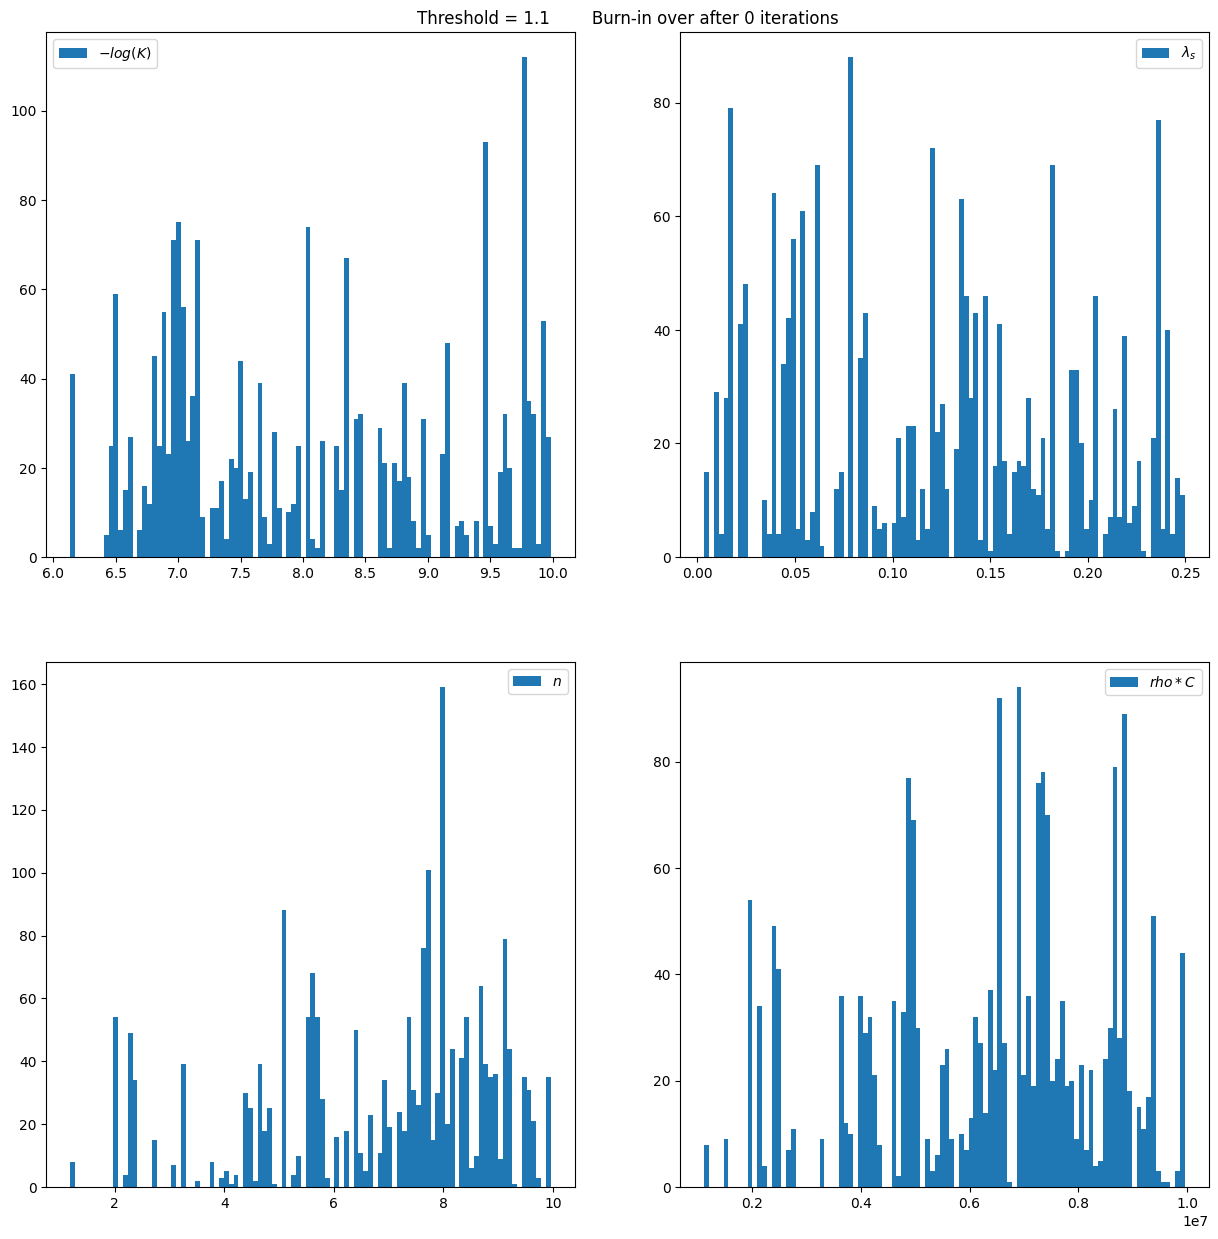

In [6]:
_params = np.array([col._states[k].layers[0].params for k in range(len(col._states))])
threshold = 1.1

plt.figure(figsize=(15,15))
plt.title(f"Threshold = {threshold}        Burn-in over after {0} iterations")
plt.axis('off')
dico = {0 : "$-log(K)$", 1 : "$\lambda_s$", 2 : "$n$", 3 : "$rho * C$"}
for k in range(nb_param):
    plt.subplot(2, 2, k+1)
    plt.hist(_params[:,k], bins = 100, label=f"{dico[k]}")
    plt.legend();
plt.savefig(f"../images/threshold_{int(threshold*100)}.png")